In [62]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

In [63]:
random_state = 2025

In [64]:
df_ipipneo_120 = pd.read_csv("../data/kaggle/IPIP120-SCORES.csv")

In [65]:
print(df_ipipneo_120.columns.tolist())

['case', 'sex', 'age', 'sec', 'min', 'hour', 'day', 'month', 'year', 'country', 'i1', 'i2', 'i3', 'i4', 'i5', 'i6', 'i7', 'i8', 'i9', 'i10', 'i11', 'i12', 'i13', 'i14', 'i15', 'i16', 'i17', 'i18', 'i19', 'i20', 'i21', 'i22', 'i23', 'i24', 'i25', 'i26', 'i27', 'i28', 'i29', 'i30', 'i31', 'i32', 'i33', 'i34', 'i35', 'i36', 'i37', 'i38', 'i39', 'i40', 'i41', 'i42', 'i43', 'i44', 'i45', 'i46', 'i47', 'i48', 'i49', 'i50', 'i51', 'i52', 'i53', 'i54', 'i55', 'i56', 'i57', 'i58', 'i59', 'i60', 'i61', 'i62', 'i63', 'i64', 'i65', 'i66', 'i67', 'i68', 'i69', 'i70', 'i71', 'i72', 'i73', 'i74', 'i75', 'i76', 'i77', 'i78', 'i79', 'i80', 'i81', 'i82', 'i83', 'i84', 'i85', 'i86', 'i87', 'i88', 'i89', 'i90', 'i91', 'i92', 'i93', 'i94', 'i95', 'i96', 'i97', 'i98', 'i99', 'i100', 'i101', 'i102', 'i103', 'i104', 'i105', 'i106', 'i107', 'i108', 'i109', 'i110', 'i111', 'i112', 'i113', 'i114', 'i115', 'i116', 'i117', 'i118', 'i119', 'i120', 'openness', 'facet_imagination', 'facet_artistic_interests', 'facet_

#### Предобработка

In [66]:
df_ipipneo_120_float_cols = df_ipipneo_120.select_dtypes(include=["float64"]).columns
df_ipipneo_120[df_ipipneo_120_float_cols] = df_ipipneo_120[df_ipipneo_120_float_cols].astype(int)
df_ipipneo_120.columns = df_ipipneo_120.columns.str.strip().str.lower()

print(f"Dataset original total: {len(df_ipipneo_120)}")
print(f"Is there any missing value? {df_ipipneo_120.isnull().values.any()}")
print(f"How many missing values: {df_ipipneo_120.isnull().values.sum()}")

print("Removing invalid data from dataset: IPIP120")
df_ipipneo_120 = df_ipipneo_120[(df_ipipneo_120.loc[:, "i1":"i120"] != 0).all(axis=1)]

df_ipipneo_120 = df_ipipneo_120.dropna(inplace=False)

print(f"New dataset total: {len(df_ipipneo_120)}")
print(f"Number of countries: {len(df_ipipneo_120.country.unique())}")

Dataset original total: 410376
Is there any missing value? True
How many missing values: 208
Removing invalid data from dataset: IPIP120
New dataset total: 410168
Number of countries: 240


## Кластеризация на аспектах личности

In [6]:
X = df_ipipneo_120.copy()

O = X.filter(
    [
        "facet_imagination",
        "facet_artistic_interests",
        "facet_emotionality",
        "facet_adventurousness",
        "facet_intellect",
        "facet_liberalism",
    ]
)
C = X.filter(
    [
        "facet_self_efficacy",
        "facet_orderliness",
        "facet_dutifulness",
        "facet_achievement_striving",
        "facet_self_discipline",
        "facet_cautiousness",
    ]
)
E = X.filter(
    [
        "facet_friendliness",
        "facet_gregariousness",
        "facet_assertiveness",
        "facet_activity_level",
        "facet_excitement_seeking",
        "facet_cheerfulness",
    ]
)
A = X.filter(
    [
        "facet_trust",
        "facet_morality",
        "facet_altruism",
        "facet_cooperation",
        "facet_modesty",
        "facet_sympathy",
    ]
)
N = X.filter(
    [
        "facet_anxiety",
        "facet_anger",
        "facet_depression",
        "facet_self_consciousness",
        "facet_immoderation",
        "facet_vulnerability",
    ]
)

model_facet = pd.concat([O, C, E, A, N], axis=1)
model_facet.head()

,facet_imagination,facet_artistic_interests,facet_emotionality,facet_adventurousness,facet_intellect,facet_liberalism,facet_self_efficacy,facet_orderliness,facet_dutifulness,facet_achievement_striving,...,facet_altruism,facet_cooperation,facet_modesty,facet_sympathy,facet_anxiety,facet_anger,facet_depression,facet_self_consciousness,facet_immoderation,facet_vulnerability
0,75,40,73,71,59,36,59,32,54,63,...,67,76,74,77,27,11,58,39,96,11
1,64,61,31,88,57,92,89,68,44,16,...,89,4,69,67,58,89,89,57,1,80
2,53,45,3,90,74,90,93,24,14,80,...,2,3,24,12,33,86,29,7,6,15
3,8,60,49,81,86,25,84,65,78,82,...,54,52,38,41,12,57,18,8,44,5
4,53,61,44,41,47,69,49,52,44,16,...,66,82,50,55,21,7,26,38,62,53


In [7]:
kmeans = KMeans(n_clusters=4, random_state=random_state)
kfit = kmeans.fit(model_facet)

predictions = kfit.labels_
model_facet["clusters"] = predictions
model_facet.head()

,facet_imagination,facet_artistic_interests,facet_emotionality,facet_adventurousness,facet_intellect,facet_liberalism,facet_self_efficacy,facet_orderliness,facet_dutifulness,facet_achievement_striving,...,facet_cooperation,facet_modesty,facet_sympathy,facet_anxiety,facet_anger,facet_depression,facet_self_consciousness,facet_immoderation,facet_vulnerability,clusters
0,75,40,73,71,59,36,59,32,54,63,...,76,74,77,27,11,58,39,96,11,1
1,64,61,31,88,57,92,89,68,44,16,...,4,69,67,58,89,89,57,1,80,2
2,53,45,3,90,74,90,93,24,14,80,...,3,24,12,33,86,29,7,6,15,2
3,8,60,49,81,86,25,84,65,78,82,...,52,38,41,12,57,18,8,44,5,1
4,53,61,44,41,47,69,49,52,44,16,...,82,50,55,21,7,26,38,62,53,2


In [8]:
facet_columns = model_facet.drop(columns=["clusters"]).columns
centroids_kmeans = pd.DataFrame(
    kfit.cluster_centers_,
    columns=facet_columns
)

centroids_kmeans["clusters"] = range(len(centroids_kmeans))
centroids_kmeans

,facet_imagination,facet_artistic_interests,facet_emotionality,facet_adventurousness,facet_intellect,facet_liberalism,facet_self_efficacy,facet_orderliness,facet_dutifulness,facet_achievement_striving,...,facet_cooperation,facet_modesty,facet_sympathy,facet_anxiety,facet_anger,facet_depression,facet_self_consciousness,facet_immoderation,facet_vulnerability,clusters
0,28.634782,34.657931,40.387592,31.896317,36.743315,39.398224,59.682338,65.519786,64.933175,60.569637,...,61.469759,52.866071,47.306181,51.576827,40.903629,40.560954,60.746477,35.647709,50.945421,0
1,36.573081,52.250005,52.311876,59.373537,52.787537,43.916233,74.070931,67.594186,68.815974,71.670749,...,66.312648,45.461943,62.285433,26.970295,26.284257,19.466409,26.233310,33.145087,27.091007,1
2,50.433914,43.338821,46.018824,54.734269,43.350181,51.032115,50.301090,42.270014,35.340953,43.425026,...,36.105140,38.426028,47.766567,45.473474,53.009329,37.109570,32.778525,59.838140,48.311237,2
3,51.269250,42.605280,47.673043,34.455076,41.639402,52.015016,27.945517,39.118906,35.578413,30.899415,...,40.925121,59.975326,46.228868,73.618478,62.483068,73.747993,72.210325,61.346720,76.717703,3


In [9]:
# Статистика по кластерам
print("\nСтатистика кластеров:")
cluster_stats = model_facet.groupby('clusters').agg({
    'facet_imagination': ['mean', 'std'],
    'facet_artistic_interests': ['mean', 'std'],
    'facet_emotionality': ['mean', 'std'],
    'facet_adventurousness': ['mean', 'std'],
    'facet_intellect': ['mean', 'std'],
    'facet_liberalism': ['mean', 'std'],
    'facet_self_efficacy': ['mean', 'std'],
    'facet_orderliness': ['mean', 'std'],
    'facet_dutifulness': ['mean', 'std'],
    'facet_achievement_striving': ['mean', 'std'],
    'facet_self_discipline': ['mean', 'std'],
    'facet_cautiousness': ['mean', 'std'],
    'facet_friendliness': ['mean', 'std'],
    'facet_gregariousness': ['mean', 'std'],
    'facet_assertiveness': ['mean', 'std'],
    'facet_activity_level': ['mean', 'std'],
    'facet_excitement_seeking': ['mean', 'std'],
    'facet_cheerfulness': ['mean', 'std'],
    'facet_trust': ['mean', 'std'],
    'facet_morality': ['mean', 'std'],
    'facet_altruism': ['mean', 'std'],
    'facet_cooperation': ['mean', 'std'],
    'facet_modesty': ['mean', 'std'],
    'facet_sympathy': ['mean', 'std'],
    'facet_anxiety': ['mean', 'std'],
    'facet_anger': ['mean', 'std'],
    'facet_depression': ['mean', 'std'],
    'facet_self_consciousness': ['mean', 'std'],
    'facet_immoderation': ['mean', 'std'],
    'facet_vulnerability': ['mean', 'std'],
}).round(3)
cluster_stats


Статистика кластеров:


facet_imagination         facet_artistic_interests          \
                      mean     std                     mean     std   
clusters                                                              
0                   28.660  26.090                   34.681  27.098   
1                   36.539  28.257                   52.212  27.627   
2                   50.429  27.179                   43.348  28.743   
3                   51.282  27.701                   42.603  28.823   

         facet_emotionality         facet_adventurousness          \
                       mean     std                  mean     std   
clusters                                                            
0                    40.398  27.085                31.888  23.982   
1                    52.290  26.483                59.344  25.724   
2                    46.026  27.752                54.749  26.444   
3                    47.674  28.565                34.455  25.965   

         facet_intellect          ... facet_anger         facet_depression  \
                    mean     std  ...        mean     std             mean   
clusters                          ...                                        
0                 36.755  27.731  ...      40.919  26.928           40.610   
1                 52.762  27.438  ...      26.285  23.384           19.463   
2                 43.363  29.004  ...      52.984  27.857           37.092   
3                 41.631  29.317  ...      62.507  27.024           73.751   

                 facet_self_consciousness         facet_immoderation          \
             std                     mean     std               mean     std   
clusters                                                                       
0         23.892                   60.794  22.433             35.664  24.536   
1         16.942                   26.251  20.398             33.126  24.540   
2         22.699                   32.764  21.772             59.822  25.316   
3         21.133                   72.194  20.734             61.372  26.761   

         facet_vulnerability          
                        mean     std  
clusters                              
0                     50.990  25.430  
1                     27.092  20.539  
2                     48.288  25.270  
3                     76.722  21.511  

[4 rows x 60 columns]

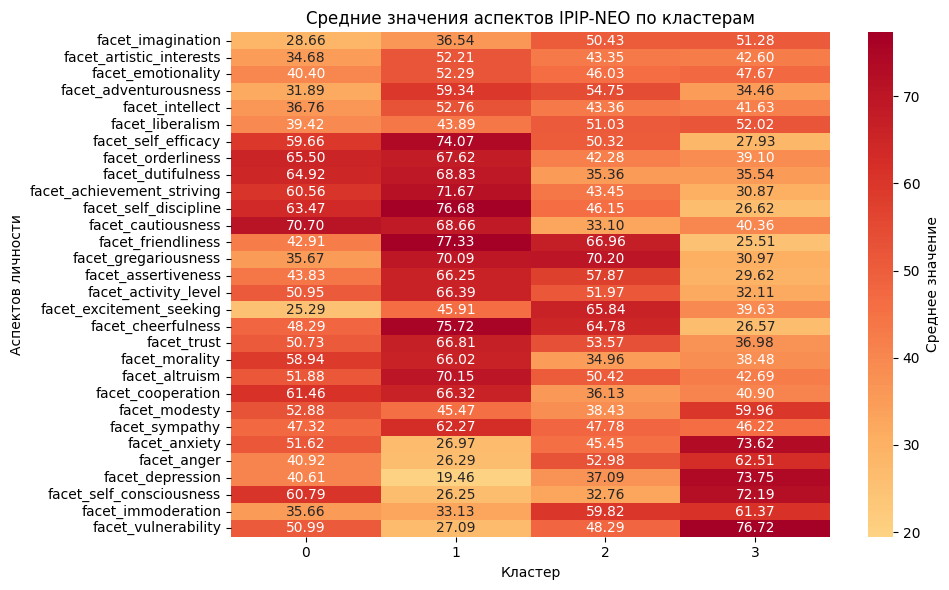

In [ ]:
# Вычисляем средние значения
cluster_means = model_facet.groupby('clusters').mean()

# Визуализация heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    cluster_means.T, 
    annot=True, 
    fmt='.2f', 
    cmap='RdYlBu_r',
    center=0,
    cbar_kws={'label': 'Среднее значение'}
)
plt.title('Средние значения аспектов IPIP-NEO по кластерам')
plt.xlabel('Кластер')
plt.ylabel('Аспектов личности')
plt.tight_layout()
plt.show()

In [11]:
pca = PCA(n_components=2)

df_pca = pd.DataFrame(data=pca.fit_transform(model_facet), columns=["X", "Y"])
df_pca["clusters"] = predictions

df_pca.head()

,X,Y,clusters
0,-35.893582,10.139424,1
1,7.944674,27.720076,2
2,-33.410238,75.074485,2
3,-102.100593,9.111700,1
4,-14.793516,10.046795,2


In [12]:
# Вычисляем центроиды кластеров в PCA пространстве
centroids = []
for cluster_id in sorted(df_pca['clusters'].unique()):
    cluster_data = df_pca[df_pca['clusters'] == cluster_id]
    centroid = cluster_data[['X', 'Y']].mean()
    centroids.append({
        'cluster': cluster_id,
        'X': centroid['X'],
        'Y': centroid['Y'],
        'size': len(cluster_data)
    })

centroids_pca = pd.DataFrame(centroids)
centroids_pca

,cluster,X,Y,size
0,0,0.032815,-51.429082,107174
1,1,-85.183939,-0.264697,108880
2,2,6.182680,56.265114,108867
3,3,100.862442,-6.859284,85247


In [13]:
df_closest_distances = pd.DataFrame(columns=df_pca.columns.tolist())

for cluster_id in sorted(centroids_pca["cluster"].unique()):
    centroid_vector = centroids_pca.loc[cluster_id, ["X", "Y"]].values
    cluster_members = df_pca[df_pca["clusters"] == cluster_id]
    distances = cluster_members.apply(
        lambda row: np.linalg.norm(row[["X", "Y"]].values - centroid_vector),
        axis=1
    )
    closest_idx = distances.idxmin()
    df_closest_distances = pd.concat([df_closest_distances, pd.DataFrame([cluster_members.loc[closest_idx]])], ignore_index=True)

df_closest_distances

C:\Users\dzapl\AppData\Local\Temp\ipykernel_8188\3075636395.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_closest_distances = pd.concat([df_closest_distances, pd.DataFrame([cluster_members.loc[closest_idx]])], ignore_index=True)


,X,Y,clusters
0,0.072872,-51.387175,0.0
1,-85.205697,-0.322400,1.0
2,6.278364,56.257894,2.0
3,100.554187,-6.866269,3.0


In [14]:
df_centroids = pd.DataFrame()
for cluster_id in sorted(centroids_pca["cluster"].unique()):
    centroid_vector = centroids_pca.loc[cluster_id, ["X", "Y"]].values
    cluster_members = df_pca[df_pca["clusters"] == cluster_id]
    distances = cluster_members.apply(
        lambda row: np.linalg.norm(row[["X", "Y"]].values - centroid_vector),
        axis=1
    )
    closest_idx = distances.idxmin()
    closest_person = pd.DataFrame([df_ipipneo_120.loc[closest_idx]])
    closest_person['clusters'] = cluster_id
    df_centroids = pd.concat([df_centroids, closest_person], ignore_index=True)

df_centroids

,case,sex,age,sec,min,hour,day,month,year,country,...,facet_modesty,facet_sympathy,neuroticism,facet_anxiety,facet_anger,facet_depression,facet_self_consciousness,facet_immoderation,facet_vulnerability,clusters
0,477323,1,20,35,15,22,26,7,107,Japan,...,75,60,3,10,1,21,28,13,15,0
1,271872,2,23,43,0,20,26,7,103,USA,...,60,31,6,49,35,12,21,1,4,1
2,285283,1,36,9,29,19,3,9,103,USA,...,55,31,62,36,82,79,30,68,48,2
3,524157,1,48,48,11,14,27,4,108,USA,...,39,69,54,61,20,60,61,57,62,3


In [31]:
closest_person_trait = df_centroids[['openness', 'conscientiousness', 'extraversion', 
                                     'agreeableness', 'neuroticism', 'clusters']]

In [35]:
closest_person_facet = df_centroids[['facet_imagination', 'facet_artistic_interests', 'facet_emotionality',
       'facet_adventurousness', 'facet_intellect', 'facet_liberalism',
       'facet_self_efficacy', 'facet_orderliness', 'facet_dutifulness',
       'facet_achievement_striving', 'facet_self_discipline',
       'facet_cautiousness', 'facet_friendliness', 'facet_gregariousness',
       'facet_assertiveness', 'facet_activity_level',
       'facet_excitement_seeking', 'facet_cheerfulness', 'facet_trust',
       'facet_morality', 'facet_altruism', 'facet_cooperation',
       'facet_modesty', 'facet_sympathy', 'facet_anxiety', 'facet_anger',
       'facet_depression', 'facet_self_consciousness', 'facet_immoderation',
       'facet_vulnerability', 'clusters']]

In [22]:
closest_person_facet.columns

Index(['facet_imagination', 'facet_artistic_interests', 'facet_emotionality',
       'facet_adventurousness', 'facet_intellect', 'facet_liberalism',
       'facet_self_efficacy', 'facet_orderliness', 'facet_dutifulness',
       'facet_achievement_striving', 'facet_self_discipline',
       'facet_cautiousness', 'facet_friendliness', 'facet_gregariousness',
       'facet_assertiveness', 'facet_activity_level',
       'facet_excitement_seeking', 'facet_cheerfulness', 'facet_trust',
       'facet_morality', 'facet_altruism', 'facet_cooperation',
       'facet_modesty', 'facet_sympathy', 'facet_anxiety', 'facet_anger',
       'facet_depression', 'facet_self_consciousness', 'facet_immoderation',
       'facet_vulnerability'],
      dtype='object')

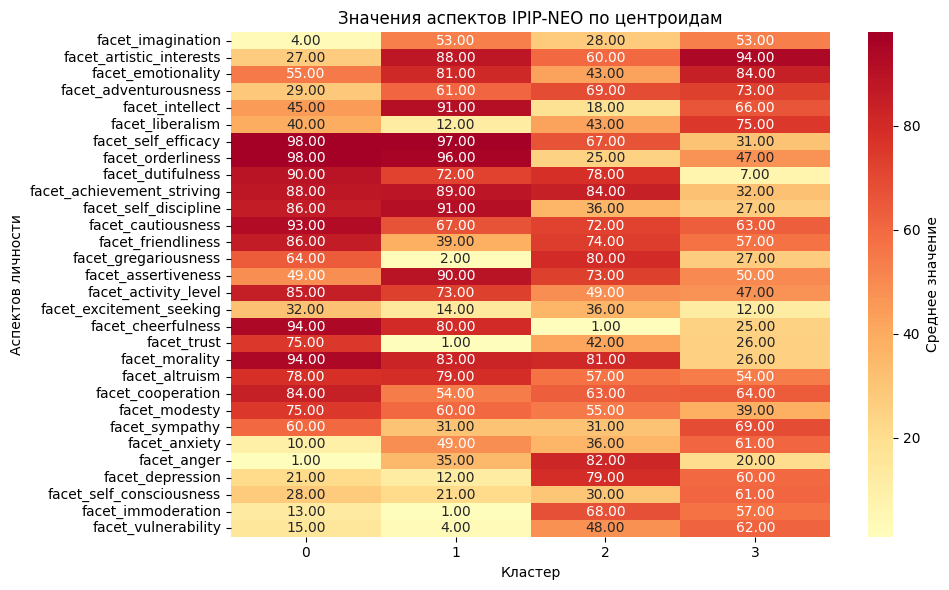

In [29]:

plt.figure(figsize=(10, 6))
sns.heatmap(
    closest_person_facet.T, 
    annot=True, 
    fmt='.2f', 
    cmap='RdYlBu_r',
    center=0,
    cbar_kws={'label': 'Среднее значение'}
)
plt.title('Значения аспектов IPIP-NEO по центроидам')
plt.xlabel('Кластер')
plt.ylabel('Аспектов личности')
plt.tight_layout()
plt.show()

In [25]:
df_pca_closest_distances = pd.DataFrame(data=pca.fit_transform(df_closest_distances.drop("clusters", axis=1)), columns=["X", "Y"])
df_pca_closest_distances["clusters"] = df_closest_distances["clusters"]

Text(0.5, 1.0, 'Cluster IPIP-NEO Facets | Visualized on PCA')

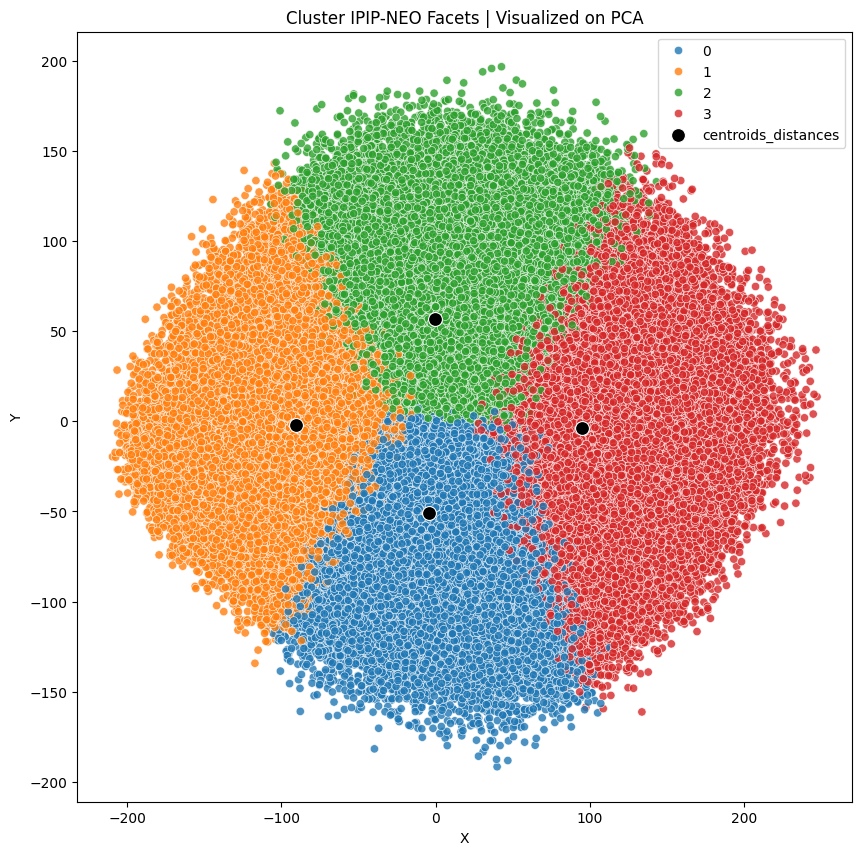

In [27]:
plt.figure(figsize=(10, 10))
sns.scatterplot(
    data=df_pca, x="X", y="Y", hue="clusters", legend="full", palette="tab10", alpha=0.8
)
sns.scatterplot(
    data=df_pca_closest_distances, x="X", y="Y", color="black", s=100, marker="o", label="centroids_distances"
)
plt.title("Cluster IPIP-NEO Facets | Visualized on PCA")

## Работа с признаками

In [32]:
closest_person_trait

,openness,conscientiousness,extraversion,agreeableness,neuroticism,clusters
0,22,99,79,90,3,0
1,74,97,45,40,6,1
2,40,63,52,57,62,2
3,88,31,30,42,54,3


In [36]:
closest_person_facet

,facet_imagination,facet_artistic_interests,facet_emotionality,facet_adventurousness,facet_intellect,facet_liberalism,facet_self_efficacy,facet_orderliness,facet_dutifulness,facet_achievement_striving,...,facet_cooperation,facet_modesty,facet_sympathy,facet_anxiety,facet_anger,facet_depression,facet_self_consciousness,facet_immoderation,facet_vulnerability,clusters
0,4,27,55,29,45,40,98,98,90,88,...,84,75,60,10,1,21,28,13,15,0
1,53,88,81,61,91,12,97,96,72,89,...,54,60,31,49,35,12,21,1,4,1
2,28,60,43,69,18,43,67,25,78,84,...,63,55,31,36,82,79,30,68,48,2
3,53,94,84,73,66,75,31,47,7,32,...,64,39,69,61,20,60,61,57,62,3


In [48]:
def select_top_facet(df, n_top=5, middle=50):
    top_features = {}
    
    for idx, row in df.iterrows():
        # Вычисляем расстояние от середины для каждого признака
        distance_from_middle = (row - middle).abs()
        
        # Сортируем по удаленности от середины
        sorted_features = distance_from_middle.sort_values(ascending=False)
        
        top_n_distances = sorted_features.head(n_top)
        
        features_info = []
        for feature in top_n_distances.index:
            original_value = row[feature]
            
            features_info.append({
                'feature': feature,
                'value': int(original_value),
            })
        
        top_features[idx] = features_info
    
    return top_features

In [ ]:
result = select_top_facet(closest_person_facet.drop('clusters',axis=1), n_top=5)
result

{0: [{'feature': 'facet_anger', 'value': 1},
  {'feature': 'facet_orderliness', 'value': 98},
  {'feature': 'facet_self_efficacy', 'value': 98},
  {'feature': 'facet_imagination', 'value': 4},
  {'feature': 'facet_cheerfulness', 'value': 94}],
 1: [{'feature': 'facet_immoderation', 'value': 1},
  {'feature': 'facet_trust', 'value': 1},
  {'feature': 'facet_gregariousness', 'value': 2},
  {'feature': 'facet_self_efficacy', 'value': 97},
  {'feature': 'facet_orderliness', 'value': 96}],
 2: [{'feature': 'facet_cheerfulness', 'value': 1},
  {'feature': 'facet_achievement_striving', 'value': 84},
  {'feature': 'facet_anger', 'value': 82},
  {'feature': 'facet_intellect', 'value': 18},
  {'feature': 'facet_morality', 'value': 81}],
 3: [{'feature': 'facet_artistic_interests', 'value': 94},
  {'feature': 'facet_dutifulness', 'value': 7},
  {'feature': 'facet_excitement_seeking', 'value': 12},
  {'feature': 'facet_emotionality', 'value': 84},
  {'feature': 'facet_anger', 'value': 20}]}

In [55]:
df_centroids

,case,sex,age,sec,min,hour,day,month,year,country,...,facet_modesty,facet_sympathy,neuroticism,facet_anxiety,facet_anger,facet_depression,facet_self_consciousness,facet_immoderation,facet_vulnerability,clusters
0,477323,1,20,35,15,22,26,7,107,Japan,...,75,60,3,10,1,21,28,13,15,0
1,271872,2,23,43,0,20,26,7,103,USA,...,60,31,6,49,35,12,21,1,4,1
2,285283,1,36,9,29,19,3,9,103,USA,...,55,31,62,36,82,79,30,68,48,2
3,524157,1,48,48,11,14,27,4,108,USA,...,39,69,54,61,20,60,61,57,62,3


In [70]:
df_ipipneo_120['clusters'] = df_pca['clusters']

In [69]:
df_pca

,X,Y,clusters
0,-35.893582,10.139424,1
1,7.944674,27.720076,2
2,-33.410238,75.074485,2
3,-102.100593,9.111700,1
4,-14.793516,10.046795,2
...,...,...,...
410163,-50.972088,42.591592,1
410164,-50.286280,9.742932,1
410165,88.690883,-126.251616,3
410166,96.135482,-5.122094,3


In [71]:
df_ipipneo_120

,case,sex,age,sec,min,hour,day,month,year,country,...,facet_modesty,facet_sympathy,neuroticism,facet_anxiety,facet_anger,facet_depression,facet_self_consciousness,facet_immoderation,facet_vulnerability,clusters
0,1,2,19,8,41,16,30,6,101,South Afr,...,74,77,35,27,11,58,39,96,11,1.0
1,2,2,22,24,45,16,30,6,101,USA,...,69,67,66,58,89,89,57,1,80,2.0
2,6,1,13,14,6,17,30,6,101,USA,...,24,12,22,33,86,29,7,6,15,2.0
3,7,2,18,25,11,17,30,6,101,USA,...,38,41,12,12,57,18,8,44,5,1.0
4,8,2,24,19,25,17,30,6,101,USA,...,50,55,26,21,7,26,38,62,53,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
410371,690852,2,29,35,18,23,15,4,111,Bulgaria,...,50,79,58,76,76,68,21,33,53,NaN
410372,690853,2,16,0,35,23,15,4,111,USA,...,57,66,1,1,6,11,30,24,1,NaN
410373,690854,2,22,9,52,23,15,4,111,USA,...,86,79,96,95,69,89,99,42,97,NaN
410374,690858,2,15,31,36,1,16,4,111,USA,...,74,66,81,75,73,92,58,44,76,NaN
